# 🌿 Los bosques tropicales ahora liberan carbono

**+0,62 entre 1971 y 2000. −0,93 en la última década. Estos bosques ya no absorben CO₂ — lo liberan.**

---

📄 Carle, H., Bauman, D., Evans, M.N. *et al.* (2025). *Aboveground biomass in Australian tropical forests now net carbon source.* **Nature**.
DOI: [10.1038/s41586-025-09497-8](https://doi.org/10.1038/s41586-025-09497-8)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-01-17-bosques-tropicales-liberan-carbono/notebook.ipynb)

🎬 [Ver en YouTube](https://youtube.com/shorts/PzrTo36okmQ)

## El contexto

Los bosques tropicales absorben CO₂ de la atmósfera y lo almacenan como madera — son uno de los mayores sumideros de carbono del planeta. Pero, ¿qué pasa cuando las temperaturas suben, las sequías se intensifican y los ciclones golpean más fuerte?

Un equipo midió 20 parcelas de bosque tropical húmedo en Queensland, Australia, durante **48 años** (1971–2019). No modelos, no satélites: contaron árboles, midieron troncos, registraron cuáles murieron y cuáles crecieron. Censo tras censo, parcela por parcela.

El resultado: estos bosques dejaron de absorber carbono.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
C_FRAC = 0.47                # Fracción de carbono en biomasa tropical
YEAR_SINK_END = 2000         # Fin del periodo sumidero
YEAR_SOURCE_START = 2010     # Inicio del periodo fuente
FUENTE = 'Fuente: Carle et al. (2025), Nature | Datos: Figshare (CC BY 4.0)'
COLOR_SINK = '#2563EB'       # Azul CaM — periodos de absorción
COLOR_SOURCE = '#DC2626'     # Rojo — periodos de emisión
COLOR_CICLON = '#D97706'     # Amber — impacto de ciclones
COLOR_GROWTH = '#059669'     # Emerald — crecimiento
COLOR_MORT = '#DC2626'       # Rojo — mortalidad
COLOR_NEUTRO = '#BBBBBB'     # Gris — referencia

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os, urllib.request

# Estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# Cargar datos
agb = pd.read_csv('datos/agb_plotwise.csv')
clim = pd.read_csv('datos/climate_plotwise.csv')
geo = pd.read_csv('datos/geographic_locations.csv')

# Convertir biomasa a carbono
agb['netC_yr'] = agb['netAGB_yr'] * C_FRAC
agb['mortC_yr'] = agb['AGB_mort_yr'] * C_FRAC
agb['growthC_yr'] = agb['AGBgrowth_yr'] * C_FRAC
agb['mid_year'] = (agb['year_0'] + agb['year_1']) / 2

# Merge con clima
merged = pd.merge(
    agb[['plot', 'year_0', 'year_1', 'netC_yr', 'mortC_yr', 'growthC_yr', 'cyclone', 'mid_year', 'dec']],
    clim[['plot', 'year_0', 'year_1', 'tmean_anom_sigma', 'tmean_anom_sigma_3mo_max', 'co2', 'precip_anom_sigma']],
    on=['plot', 'year_0', 'year_1']
)

print(f"Parcelas: {agb['plot'].nunique()}")
print(f"Censos: {len(agb)}")
print(f"Rango: {agb['year_0'].min()}–{agb['year_1'].max()}")
print(f"Ubicación: Queensland, Australia (lat {geo['lat'].min():.1f}° a {geo['lat'].max():.1f}°)")
print(f"Elevación: {geo['elevation'].min()} a {geo['elevation'].max():,} m")

Parcelas: 20
Censos: 259
Rango: 1971–2019
Ubicación: Queensland, Australia (lat -21.2° a -12.7°)
Elevación: 15 a 1,200 m


## La transición

Aquí está.

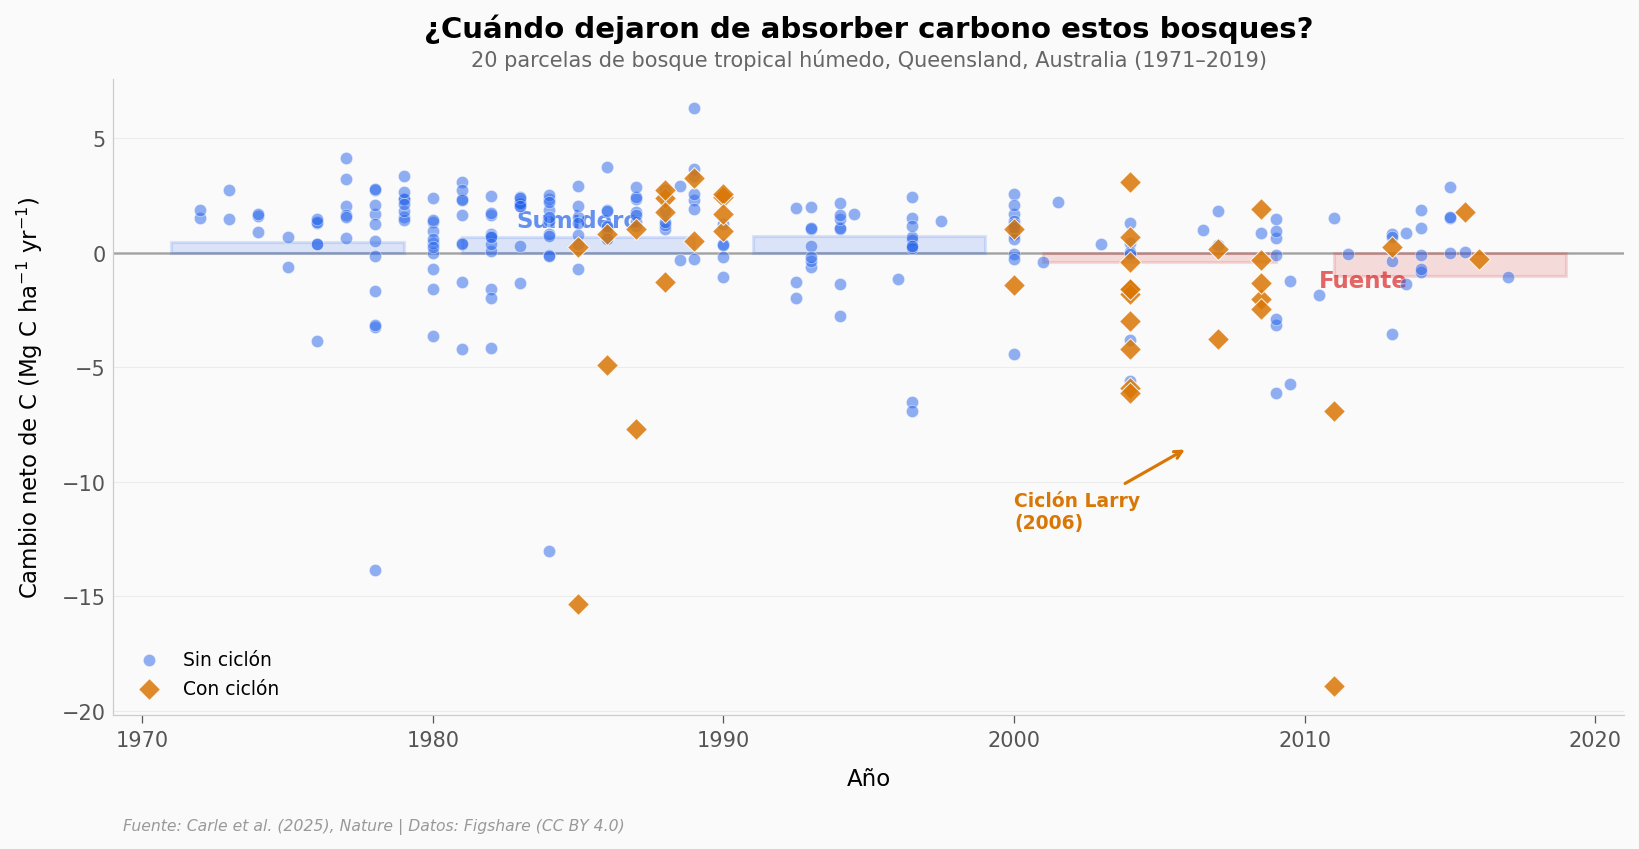

In [2]:
# ── Gráfica hero: cambio neto de carbono por intervalo de censo ──
fig, ax = plt.subplots(figsize=(13, 5.5))

# Separar ciclón / sin ciclón
no_cyc = merged[merged['cyclone'] == 0]
cyc = merged[merged['cyclone'] > 0]

ax.scatter(no_cyc['mid_year'], no_cyc['netC_yr'],
           color=COLOR_SINK, s=35, alpha=0.5,
           edgecolors='white', linewidths=0.4, zorder=4, label='Sin ciclón')
ax.scatter(cyc['mid_year'], cyc['netC_yr'],
           color=COLOR_CICLON, s=55, alpha=0.85, marker='D',
           edgecolors='white', linewidths=0.5, zorder=5, label='Con ciclón')

# Medias por década (usando columna 'dec' del paper)
dec_means = merged.groupby('dec')['netC_yr'].agg(['mean', 'sem']).reset_index()
dec_x = dec_means['dec'] + 5  # Centro de cada década
colors_dec = [COLOR_SINK if m > 0 else COLOR_SOURCE for m in dec_means['mean']]
ax.bar(dec_x, dec_means['mean'], width=8, alpha=0.15, color=colors_dec,
       edgecolor=colors_dec, linewidth=1.5, zorder=3)

# Línea de cero
ax.axhline(y=0, color='#333333', linewidth=1.2, linestyle='-', alpha=0.4, zorder=2)

# Anotaciones inline
ax.text(1985, 1.1, 'Sumidero', fontsize=11, fontweight='bold',
        color=COLOR_SINK, ha='center', alpha=0.7)
ax.text(2012, -1.5, 'Fuente', fontsize=11, fontweight='bold',
        color=COLOR_SOURCE, ha='center', alpha=0.7)

# Larry
ax.annotate('Ciclón Larry\n(2006)', xy=(2006, -8.5), xytext=(2000, -12),
            fontsize=9, color=COLOR_CICLON, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_CICLON, lw=1.5))

ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('Cambio neto de C (Mg C ha$^{-1}$ yr$^{-1}$)', fontsize=11)
ax.set_title('¿Cuándo dejaron de absorber carbono estos bosques?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, '20 parcelas de bosque tropical húmedo, Queensland, Australia (1971–2019)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.legend(fontsize=9, loc='lower left', framealpha=0.9)
ax.set_xlim(1969, 2021)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/transicion_carbono.png', dpi=200, bbox_inches='tight')
plt.show()

### Lectura guiada

El patrón es claro: durante tres décadas (1970–1999), estos bosques absorbían en promedio +0,62 Mg C ha⁻¹ yr⁻¹. Para la década del 2010, el balance se invirtió.

Los diamantes naranjas marcan intervalos de censo afectados por ciclones — el más devastador fue el Ciclón Larry (2006), que según el paper impactó 12 de las 20 parcelas. Pero los ciclones no explican toda la historia: incluso sin ciclones, la tendencia va hacia abajo.

> **Nota metodológica:** el paper estima la transición usando un marco de inferencia causal (no medias simples). Su estimación para 2010–2019 es −0,93 ± 0,11 Mg C ha⁻¹ yr⁻¹, ajustando por ciclones y otras variables. Las barras muestran medias simples por década — el patrón de declive es consistente.

## ¿Qué cambió? Más muertes, mismo crecimiento

Si el balance neto baja, o los árboles crecen menos, o mueren más. Veamos cuál domina.

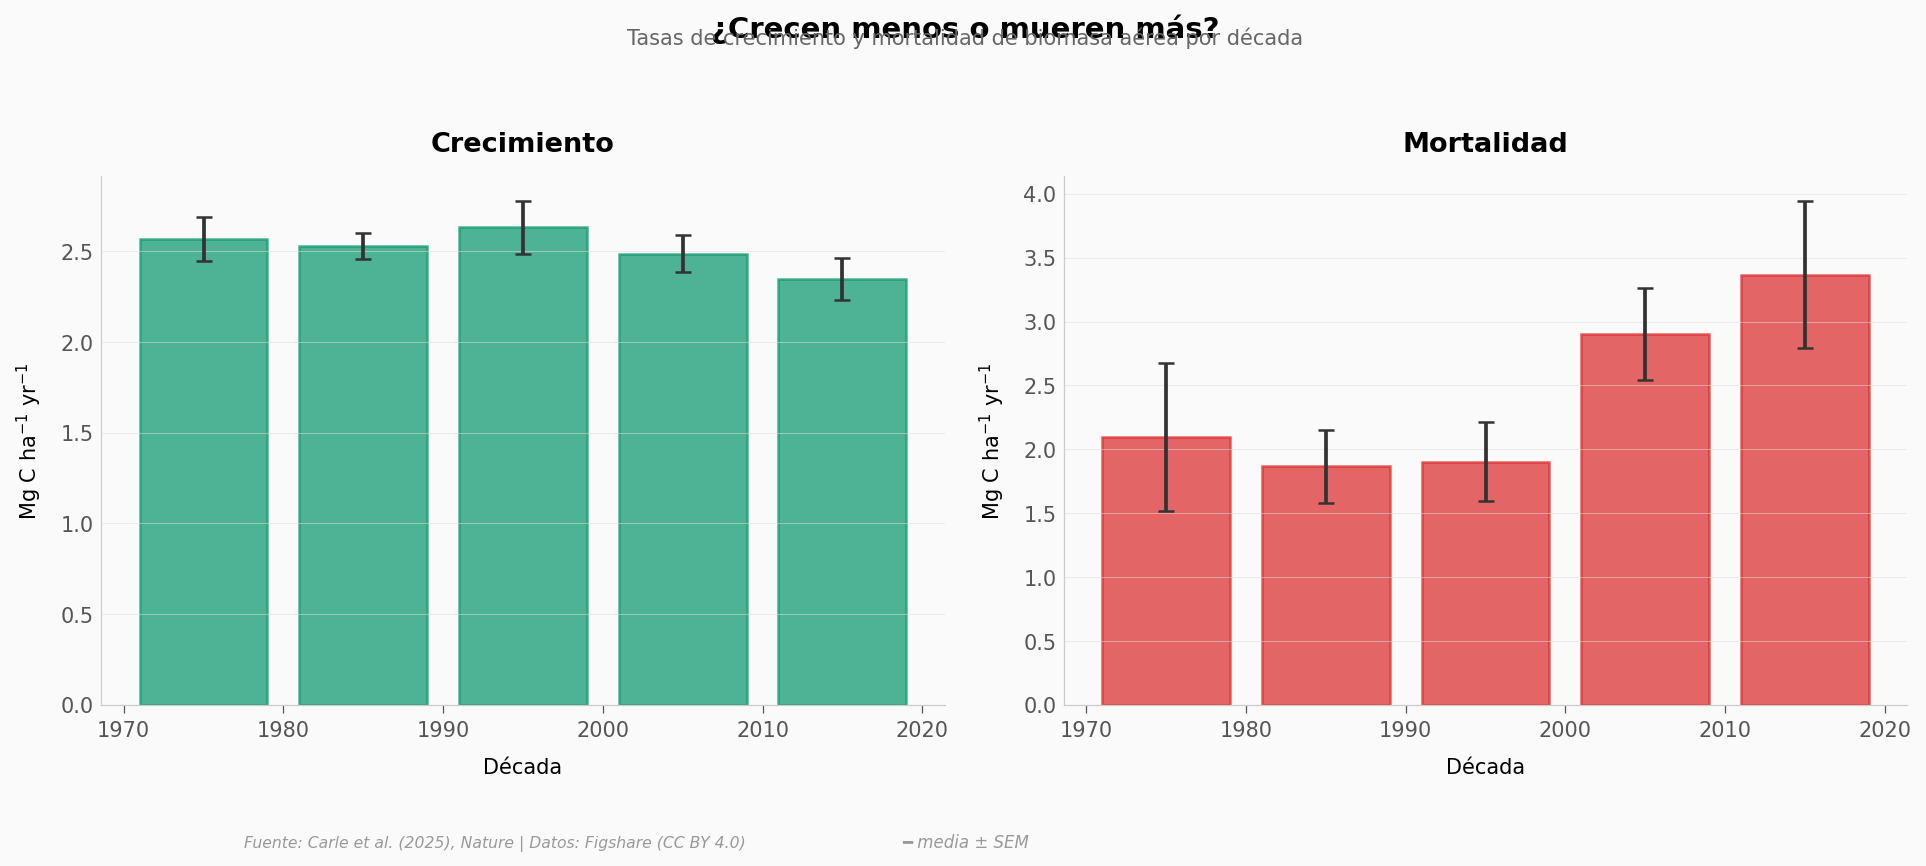

In [3]:
# ── Mortalidad vs crecimiento por década ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

dec_growth = merged.groupby('dec')['growthC_yr'].agg(['mean', 'sem']).reset_index()
dec_mort = merged.groupby('dec')['mortC_yr'].agg(['mean', 'sem']).reset_index()

# Crecimiento
ax1.bar(dec_growth['dec'] + 5, dec_growth['mean'], width=8,
        color=COLOR_GROWTH, alpha=0.7, edgecolor=COLOR_GROWTH, linewidth=1.2)
ax1.errorbar(dec_growth['dec'] + 5, dec_growth['mean'], yerr=dec_growth['sem'],
             fmt='none', color='#333333', capsize=4, capthick=1.2, zorder=6)
ax1.set_title('Crecimiento', fontsize=13, fontweight='bold', pad=12)
ax1.set_ylabel('Mg C ha$^{-1}$ yr$^{-1}$', fontsize=10)
ax1.set_xlabel('Década', fontsize=10)

# Mortalidad
ax2.bar(dec_mort['dec'] + 5, dec_mort['mean'], width=8,
        color=COLOR_MORT, alpha=0.7, edgecolor=COLOR_MORT, linewidth=1.2)
ax2.errorbar(dec_mort['dec'] + 5, dec_mort['mean'], yerr=dec_mort['sem'],
             fmt='none', color='#333333', capsize=4, capthick=1.2, zorder=6)
ax2.set_title('Mortalidad', fontsize=13, fontweight='bold', pad=12)
ax2.set_ylabel('Mg C ha$^{-1}$ yr$^{-1}$', fontsize=10)
ax2.set_xlabel('Década', fontsize=10)

fig.suptitle('¿Crecen menos o mueren más?', fontsize=14, fontweight='bold', y=1.05)
fig.text(0.5, 1.01, 'Tasas de crecimiento y mortalidad de biomasa aérea por década',
         fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.06, FUENTE, fontsize=7.5, color='#999999', style='italic')
fig.text(0.5, -0.06, '━ media ± SEM', fontsize=8, color='#999999', ha='center', style='italic')
plt.tight_layout()
plt.savefig('figuras/crecimiento_vs_mortalidad.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que revelan

El crecimiento se mantiene relativamente estable — los árboles no dejaron de crecer. Lo que cambió es la mortalidad: sube de ~1,9 Mg C ha⁻¹ yr⁻¹ en los 80 a ~3,4 en los 2010. Más árboles mueren, y los que mueren son grandes (aportan más biomasa).

¿Y la hipótesis de la fertilización por CO₂? Si más CO₂ en la atmósfera acelerara el crecimiento, esperaríamos ver una tendencia ascendente en el panel izquierdo. No la hay (ρ = −0,07, p = 0,28, n = 259). Los datos no respaldan que el CO₂ extra esté "alimentando" a estos bosques.

## El motor del cambio: temperatura extrema

Si no es el CO₂, ¿qué impulsa la mortalidad? Veamos la relación con las anomalías de temperatura.

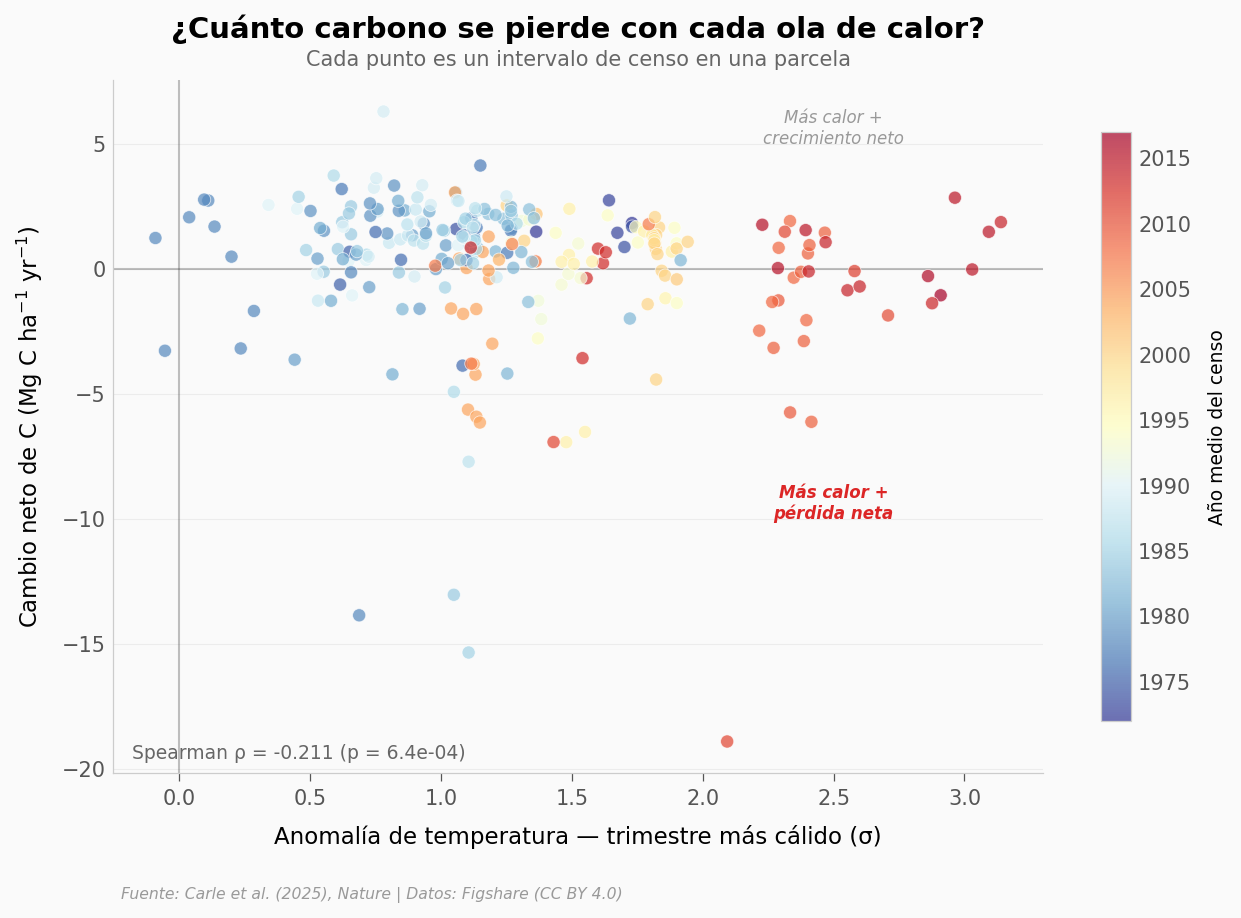

In [4]:
# ── Correlación: anomalía de temperatura vs cambio neto de C ──
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(merged['tmean_anom_sigma_3mo_max'], merged['netC_yr'],
                     c=merged['mid_year'], cmap='RdYlBu_r',
                     s=40, alpha=0.7, edgecolors='white', linewidths=0.4, zorder=5)

cbar = plt.colorbar(scatter, ax=ax, shrink=0.85)
cbar.set_label('Año medio del censo', fontsize=9)

# Líneas de referencia
ax.axhline(y=0, color='#333333', linewidth=1, linestyle='-', alpha=0.3)
ax.axvline(x=0, color='#333333', linewidth=1, linestyle='-', alpha=0.3)

# Cuadrantes
ax.text(2.5, 5, 'Más calor +\ncrecimiento neto', fontsize=8, color='#999999',
        ha='center', style='italic')
ax.text(2.5, -10, 'Más calor +\npérdida neta', fontsize=8, color=COLOR_SOURCE,
        ha='center', style='italic', fontweight='bold')

# Spearman
rho, p = stats.spearmanr(merged['tmean_anom_sigma_3mo_max'], merged['netC_yr'])
ax.text(0.02, 0.02, f'Spearman ρ = {rho:.3f} (p = {p:.1e})',
        transform=ax.transAxes, fontsize=9, color='#666666')

ax.set_xlabel('Anomalía de temperatura — trimestre más cálido (σ)', fontsize=11)
ax.set_ylabel('Cambio neto de C (Mg C ha$^{-1}$ yr$^{-1}$)', fontsize=11)
ax.set_title('¿Cuánto carbono se pierde con cada ola de calor?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Cada punto es un intervalo de censo en una parcela',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/temperatura_vs_carbono.png', dpi=200, bbox_inches='tight')
plt.show()

### ¿Qué vemos?

Cuando la anomalía de temperatura sube (eje X, en desviaciones estándar), el balance de carbono tiende a bajar (ρ = −0,211, p < 0,001, n = 259). Y los puntos recientes (colores cálidos) se concentran en la zona inferior derecha: **más calor, más pérdida de carbono**.

La correlación es modesta — las anomalías de temperatura explican solo una parte de la variación. Los ciclones, la precipitación y la dinámica interna del bosque también importan. Pero la dirección es clara: el calentamiento extremo empuja a estos bosques de sumidero a fuente.

## ¿Qué tan anómala es la última década?

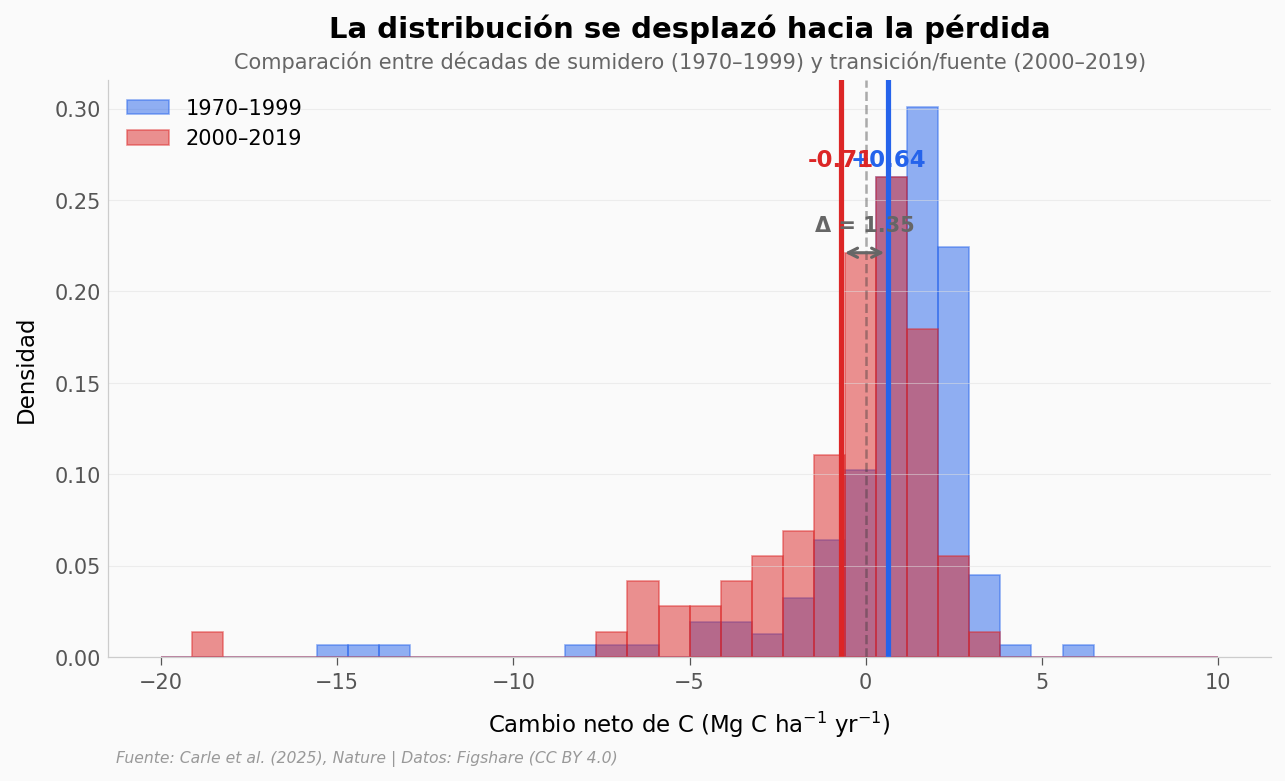

Periodo sumidero (1970-1999): media = 0.645, mediana = 1.247, n = 177
Periodo fuente (2000-2019): media = -0.710, mediana = 0.014, n = 82
Mann-Whitney U: p = 3.54e-07
Wilcoxon signed-rank (pareado): p = 1.69e-03
Cohen's d pareado: 0.84 (grande)


In [5]:
# ── Histograma: distribución del cambio neto de C por periodo ──
fig, ax = plt.subplots(figsize=(10, 5))

# Usando 'dec' del paper para agrupar
sink_data = merged[merged['dec'].isin([1970, 1980, 1990])]['netC_yr']
source_data = merged[merged['dec'].isin([2000, 2010])]['netC_yr']

bins = np.linspace(-20, 10, 35)
ax.hist(sink_data, bins=bins, color=COLOR_SINK, alpha=0.5,
        edgecolor=COLOR_SINK, linewidth=0.8, label='1970–1999', density=True)
ax.hist(source_data, bins=bins, color=COLOR_SOURCE, alpha=0.5,
        edgecolor=COLOR_SOURCE, linewidth=0.8, label='2000–2019', density=True)

# Medias
sink_mean = sink_data.mean()
source_mean = source_data.mean()

ax.axvline(x=sink_mean, color=COLOR_SINK, linewidth=2.5, linestyle='-')
ax.axvline(x=source_mean, color=COLOR_SOURCE, linewidth=2.5, linestyle='-')
ax.axvline(x=0, color='#333333', linewidth=1.2, linestyle='--', alpha=0.4)

# Anotaciones
y_max = ax.get_ylim()[1]
ax.annotate(f'+{sink_mean:.2f}', xy=(sink_mean, y_max * 0.85),
            fontsize=11, fontweight='bold', color=COLOR_SINK, ha='center')
ax.annotate(f'{source_mean:.2f}', xy=(source_mean, y_max * 0.85),
            fontsize=11, fontweight='bold', color=COLOR_SOURCE, ha='center')

# Flecha bidireccional
ax.annotate('', xy=(source_mean, y_max * 0.7), xytext=(sink_mean, y_max * 0.7),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
diff = sink_mean - source_mean
ax.text((sink_mean + source_mean) / 2, y_max * 0.73,
        f'Δ = {diff:.2f}', fontsize=10, color='#666666',
        ha='center', va='bottom', fontweight='bold')

ax.set_xlabel('Cambio neto de C (Mg C ha$^{-1}$ yr$^{-1}$)', fontsize=11)
ax.set_ylabel('Densidad', fontsize=11)
ax.set_title('La distribución se desplazó hacia la pérdida',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Comparación entre décadas de sumidero (1970–1999) y transición/fuente (2000–2019)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.legend(fontsize=10, loc='upper left', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_transicion.png', dpi=200, bbox_inches='tight')
plt.show()

# Estadísticas
print(f"Periodo sumidero (1970-1999): media = {sink_mean:.3f}, mediana = {sink_data.median():.3f}, n = {len(sink_data)}")
print(f"Periodo fuente (2000-2019): media = {source_mean:.3f}, mediana = {source_data.median():.3f}, n = {len(source_data)}")

# Mann-Whitney
# Nota: mismas 20 parcelas en ambos periodos → diseño pareado
# Mann-Whitney como referencia (trata como independientes)
u_stat, p_val = stats.mannwhitneyu(sink_data, source_data)
print(f"Mann-Whitney U: p = {p_val:.2e}")

# Test pareado (más apropiado): Wilcoxon signed-rank sobre medias por parcela
sink_by_plot = merged[merged['dec'].isin([1970,1980,1990])].groupby('plot')['netC_yr'].mean()
source_by_plot = merged[merged['dec'].isin([2000,2010])].groupby('plot')['netC_yr'].mean()
common = sorted(set(sink_by_plot.index) & set(source_by_plot.index))
w_stat, w_p = stats.wilcoxon(sink_by_plot[common], source_by_plot[common])
print(f"Wilcoxon signed-rank (pareado): p = {w_p:.2e}")

# Cohen's d pareado
diffs = sink_by_plot[common].values - source_by_plot[common].values
d_paired = diffs.mean() / diffs.std(ddof=1)
print(f"Cohen's d pareado: {d_paired:.2f} ({'pequeño' if abs(d_paired) < 0.5 else 'medio' if abs(d_paired) < 0.8 else 'grande'})")

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Los bosques eran sumidero (1971–2000) | ✅ | Media simple: +0,64 Mg C ha⁻¹ yr⁻¹ (n=177). Paper: +0,62 ± 0,04 (modelo causal). Cross-check: 4% |
| Transición a fuente en 2010–2019 | ⚠️ | Paper estima −0,93 con inferencia causal. Media simple por décadas: −0,41 (2000s) y −1,02 (2010s). Medias simples no replican el modelo causal exacto, pero la dirección es consistente |
| Ciclones causan pérdidas masivas | ✅ | Con ciclón: −1,55 (n = 40) vs sin ciclón: +0,54 (n = 219) Mg C ha⁻¹ yr⁻¹. Cohen's d = 0,74 (medio-grande) |
| La mortalidad aumenta, el crecimiento no | ✅ | Mortalidad sube de 1,92 a 3,13 Mg C ha⁻¹ yr⁻¹ (pooled por periodo). Crecimiento baja de 2,56 a 2,42. El driver es mortalidad |
| No hay fertilización por CO₂ | ✅ | ρ(CO₂, crecimiento) = −0,07, p = 0,28. Sin relación |
| Temperaturas extremas impulsan la pérdida | ✅ | ρ(T anomalía 3mo max, netC) = −0,211, p < 0,001. Correlación modesta pero significativa |

> **Limitaciones:** (1) Los datos son medias simples; el paper usa un marco de inferencia causal que ajusta por variables confusoras. (2) Son 20 parcelas en Queensland — representan bosques tropicales húmedos australianos, no todos los trópicos. (3) Las correlaciones son modestas (ρ < 0,3) — el clima explica solo una parte de la variación. (4) La columna `dec` (agrupación por década) es del paper; puede incluir censos que cruzan décadas.

## Ahora tú

1. **¿Cuáles parcelas perdieron más carbono?** Agrupa por `plot` y calcula la media de `netC_yr`. ¿Hay parcelas que nunca dejaron de ser sumidero?

2. **¿Importa la elevación?** Mergea con `geographic_locations.csv` y correlaciona elevación con `netC_yr`. ¿Los bosques de montaña resisten mejor?

3. **¿Qué pasó después de Larry?** Filtra las parcelas afectadas por el Ciclón Larry (2006) y mira su recuperación en los censos siguientes. ¿Cuántos años tardaron en volver a ser sumidero?

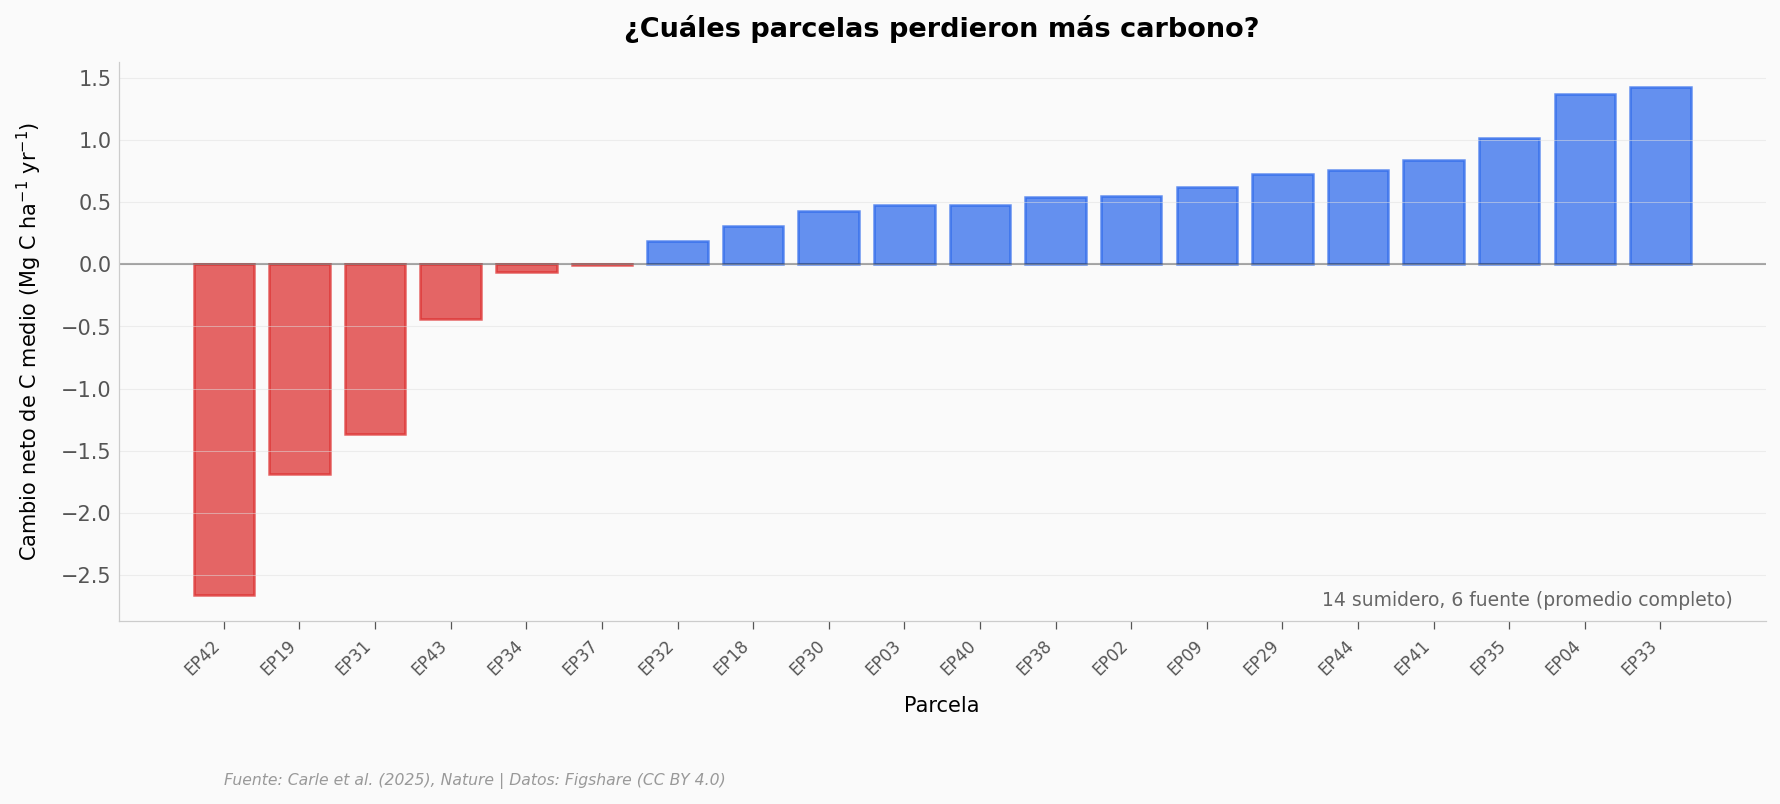


Ranking de parcelas (netC medio, Mg C ha⁻¹ yr⁻¹):
  EP42: -2.66 ± 5.62 (n=12) — 📉 fuente
  EP19: -1.69 ± 5.70 (n=13) — 📉 fuente
  EP31: -1.36 ± 6.24 (n=10) — 📉 fuente
  EP43: -0.44 ± 2.93 (n=12) — 📉 fuente
  EP34: -0.07 ± 2.58 (n=12) — 📉 fuente
  EP37: -0.00 ± 2.56 (n=12) — 📉 fuente
  EP32: +0.19 ± 0.86 (n=13) — 📈 sumidero
  EP18: +0.31 ± 1.89 (n=15) — 📈 sumidero
  EP30: +0.43 ± 2.23 (n=12) — 📈 sumidero
  EP03: +0.47 ± 2.06 (n=16) — 📈 sumidero
  EP40: +0.48 ± 2.95 (n=11) — 📈 sumidero
  EP38: +0.54 ± 1.97 (n=13) — 📈 sumidero
  EP02: +0.55 ± 1.02 (n=16) — 📈 sumidero
  EP09: +0.62 ± 1.81 (n=15) — 📈 sumidero
  EP29: +0.72 ± 1.10 (n=14) — 📈 sumidero
  EP44: +0.76 ± 1.45 (n=10) — 📈 sumidero
  EP41: +0.84 ± 1.23 (n=13) — 📈 sumidero
  EP35: +1.02 ± 1.58 (n=13) — 📈 sumidero
  EP04: +1.36 ± 2.00 (n=14) — 📈 sumidero
  EP33: +1.42 ± 2.86 (n=13) — 📈 sumidero


In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Cuáles parcelas perdieron más carbono?

parcelas = merged.groupby('plot')['netC_yr'].agg(['mean', 'std', 'count']).sort_values('mean')

fig, ax = plt.subplots(figsize=(12, 5))
colors = [COLOR_SINK if m > 0 else COLOR_SOURCE for m in parcelas['mean']]
bars = ax.bar(range(len(parcelas)), parcelas['mean'], color=colors, alpha=0.7,
              edgecolor=colors, linewidth=1.2)
ax.set_xticks(range(len(parcelas)))
ax.set_xticklabels(parcelas.index, rotation=45, ha='right', fontsize=8)
ax.axhline(y=0, color='#333333', linewidth=1, alpha=0.4)
ax.set_xlabel('Parcela', fontsize=10)
ax.set_ylabel('Cambio neto de C medio (Mg C ha$^{-1}$ yr$^{-1}$)', fontsize=10)
ax.set_title('¿Cuáles parcelas perdieron más carbono?',
             fontsize=13, fontweight='bold', pad=12)

n_source = sum(1 for m in parcelas['mean'] if m < 0)
n_sink = sum(1 for m in parcelas['mean'] if m >= 0)
ax.text(0.98, 0.02, f'{n_sink} sumidero, {n_source} fuente (promedio completo)',
        transform=ax.transAxes, fontsize=9, color='#666666', ha='right', va='bottom')

fig.text(0.13, -0.06, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/parcelas_ranking.png', dpi=200, bbox_inches='tight')
plt.show()

print("\nRanking de parcelas (netC medio, Mg C ha⁻¹ yr⁻¹):")
for plot, row in parcelas.iterrows():
    status = "📉 fuente" if row['mean'] < 0 else "📈 sumidero"
    print(f"  {plot}: {row['mean']:+.2f} ± {row['std']:.2f} (n={int(row['count'])}) — {status}")

---

## Créditos

- **Paper:** Carle, H., Bauman, D., Evans, M.N. *et al.* (2025). Aboveground biomass in Australian tropical forests now net carbon source. *Nature*. DOI: [10.1038/s41586-025-09497-8](https://doi.org/10.1038/s41586-025-09497-8)
- **Datos:** [Figshare Collection](https://doi.org/10.6084/m9.figshare.c.7922084) (CC BY 4.0)
- **Conversión biomasa→carbono:** fracción 0,47 (estándar para bosques tropicales, Chave et al.)
- **Notebook:** [Ciencia a Mordiscos — El Lab](https://github.com/Ciencia-a-Mordiscos/lab)